In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Открытие данных

In [ ]:
file_name = 'gym_churn.csv'
gym_churn = pd.read_csv('gym_churn.csv')

In [ ]:
gym_churn.sample(10)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn,cluster
2907,0,0,0,0,1,1,0,21,130.740542,1.0,0,1.486515,0.435067,1,1
3429,1,1,0,1,1,6,1,24,113.033987,6.0,4,2.096530,2.074320,0,3
1199,1,1,1,0,0,6,1,22,273.479474,5.0,2,1.052673,1.025595,0,1
722,0,1,0,0,1,12,1,24,241.291955,12.0,2,2.051571,1.920687,0,0
1632,0,1,1,1,1,1,0,27,228.196059,1.0,0,1.760984,1.345533,1,3
3173,0,1,0,0,1,12,1,24,44.037018,11.0,5,3.428673,3.469711,0,0
2260,0,0,1,0,1,1,0,23,324.452775,1.0,3,3.432550,3.359160,0,2
2061,1,1,1,1,0,12,1,31,286.666973,11.0,9,2.225451,2.081698,0,0
3148,0,1,0,0,1,6,0,26,276.972724,6.0,2,1.302346,1.354337,0,1
3472,1,0,0,0,1,1,1,27,23.366141,1.0,11,2.453019,2.421933,0,2


In [ ]:
gym_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

# Предобработка данных


> Переведем данные в более удобный для работы тип, из столбцов:

* gender => object
* Near_Location => bool
* Partner => bool
* Promo_friends => bool
* Phone => bool
* Group_visits => bool
* Month_to_end_contract => int
* Churn => bool

Поле перевода значений столбцов в новые типы, мы сможем сократить объем обрабатываемых данных, без уменьшения количетсва информации, что ускорит процесс обучения модели



In [ ]:
gym_churn['gender'] = gym_churn['gender'].astype('object')
gym_churn['Near_Location'] = gym_churn['Near_Location'].astype('bool')
gym_churn['Partner'] = gym_churn['Partner'].astype('bool')
gym_churn['Promo_friends'] = gym_churn['Promo_friends'].astype('bool')
gym_churn['Phone'] = gym_churn['Phone'].astype('bool')
gym_churn['Group_visits'] = gym_churn['Group_visits'].astype('bool')
gym_churn['Month_to_end_contract'] = gym_churn['Month_to_end_contract'].astype('int')
gym_churn['Churn'] = gym_churn['Churn'].astype('bool')

In [ ]:
gym_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   object 
 1   Near_Location                      4000 non-null   bool   
 2   Partner                            4000 non-null   bool   
 3   Promo_friends                      4000 non-null   bool   
 4   Phone                              4000 non-null   bool   
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   bool   
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   int64  
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [ ]:
gym_churn.describe().T

,count,mean,std,min,25%,50%,75%,max
Contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
Age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
Avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
Month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000
Lifetime,4000.0,3.724750,3.749267,0.000000,1.000000,3.000000,5.000000,31.000000
Avg_class_frequency_total,4000.0,1.879020,0.972245,0.000000,1.180875,1.832768,2.536078,6.023668
Avg_class_frequency_current_month,4000.0,1.767052,1.052906,0.000000,0.963003,1.719574,2.510336,6.146783


Среднее значение в группе


In [ ]:
gym_churn.groupby('Churn').agg('mean')

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
False,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
True,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


# Распеделение значений признаков

## Бинарные признаки


Близость проживания или работы

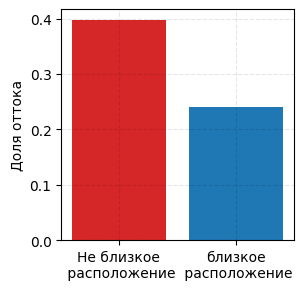

In [ ]:
name = 'Near_Location'
ticks = ['Не близкое\n расположение','близкое\n расположение']

data = gym_churn.groupby(name).agg({ 'Churn' : 'mean' }).reset_index()
bar_color = ['tab:red','tab:blue']
plt.figure(figsize=(3,3))
plt.bar(ticks,data['Churn'], color=bar_color)
plt.xlabel('')
plt.ylabel('Доля оттока')
plt.grid(linestyle='--',alpha=0.1,color='black')
plt.show()

Факт работы в компании партнере

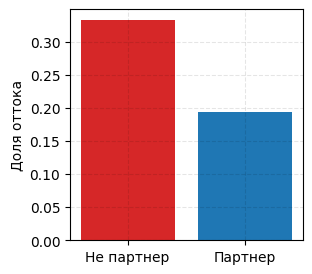

In [ ]:
name = 'Partner'
ticks = ['Не партнер','Партнер']

data = gym_churn.groupby(name).agg({ 'Churn' : 'mean' }).reset_index()
bar_color = ['tab:red','tab:blue']
plt.figure(figsize=(3,3))
plt.bar(ticks,data['Churn'], color=bar_color)
plt.xlabel('')
plt.ylabel('Доля оттока')
plt.grid(linestyle='--',alpha=0.1,color='black')
plt.show()

Факт запии по промо-акции

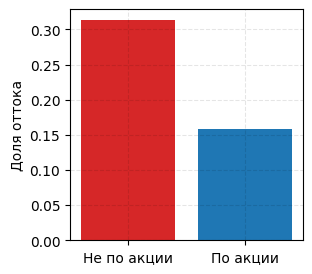

In [ ]:
name = 'Promo_friends'
ticks = ['Не по акции','По акции']

data = gym_churn.groupby(name).agg({ 'Churn' : 'mean' }).reset_index()
bar_color = ['tab:red','tab:blue']
plt.figure(figsize=(3,3))
plt.bar(ticks,data['Churn'], color=bar_color)
plt.xlabel('')
plt.ylabel('Доля оттока')
plt.grid(linestyle='--',alpha=0.1,color='black')
plt.show()

Факт наличия номера телефона

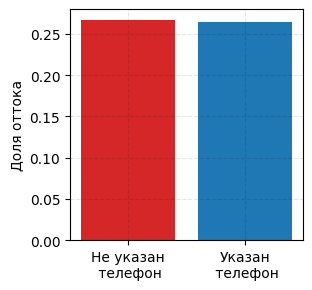

In [ ]:
name = 'Phone'
ticks = ['Не указан\n телефон','Указан\n телефон']

data = gym_churn.groupby(name).agg({ 'Churn' : 'mean' }).reset_index()
bar_color = ['tab:red','tab:blue']
plt.figure(figsize=(3,3))
plt.bar(ticks,data['Churn'], color=bar_color)
plt.xlabel('')
plt.ylabel('Доля оттока')
plt.grid(linestyle='--',alpha=0.1,color='black')
plt.show()

Факт посещения групповых тренировок

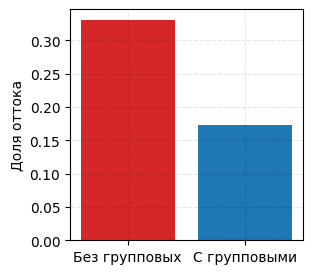

In [ ]:
name = 'Group_visits'
ticks = ['Без групповых','С групповыми']

data = gym_churn.groupby(name).agg({ 'Churn' : 'mean' }).reset_index()
bar_color = ['tab:red','tab:blue']
plt.figure(figsize=(3,3))
plt.bar(ticks,data['Churn'], color=bar_color)
plt.xlabel('')
plt.ylabel('Доля оттока')
plt.grid(linestyle='--',alpha=0.1,color='black')
plt.show()

# Категориальные признаки


Пол


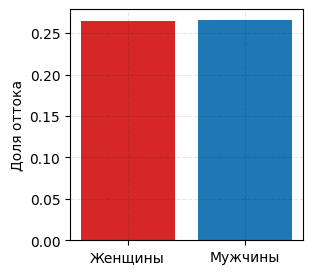

In [ ]:
name = 'gender'
ticks = ['Женщины','Мужчины']

data = gym_churn.groupby(name).agg({ 'Churn' : 'mean' }).reset_index()
bar_color = ['tab:red','tab:blue']
plt.figure(figsize=(3,3))
plt.bar(ticks,data['Churn'], color=bar_color)
plt.xlabel('')
plt.ylabel('Доля оттока')
plt.grid(linestyle='--',alpha=0.1,color='black')
plt.show()

Длительность текущего абонемента

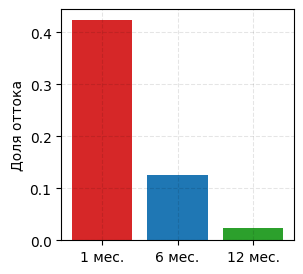

In [ ]:
name = 'Contract_period'
ticks = ['1 мес.','6 мес.','12 меc.']

data = gym_churn.groupby(name).agg({ 'Churn' : 'mean' }).reset_index()
bar_color = ['tab:red','tab:blue','tab:green']
plt.figure(figsize=(3,3))
plt.bar(ticks,data['Churn'], color=bar_color)
plt.xlabel('')
plt.ylabel('Доля оттока')
plt.grid(linestyle='--',alpha=0.1,color='black')
plt.show()

Число месяцев до окончания текущего абонемента

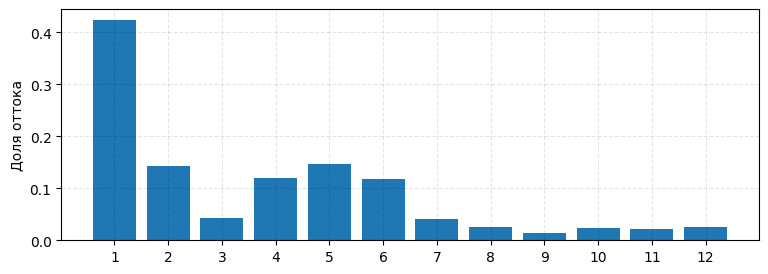

In [ ]:
name = 'Month_to_end_contract'
ticks = [str(i) for i in range(1,13)]

data = gym_churn.groupby(name).agg({ 'Churn' : 'mean' }).reset_index()
plt.figure(figsize=(9,3))
plt.bar(ticks,data['Churn'])
plt.xlabel('')
plt.ylabel('Доля оттока')
plt.grid(linestyle='--',alpha=0.1,color='black')
plt.show()

# Количественные признаки

Возраст



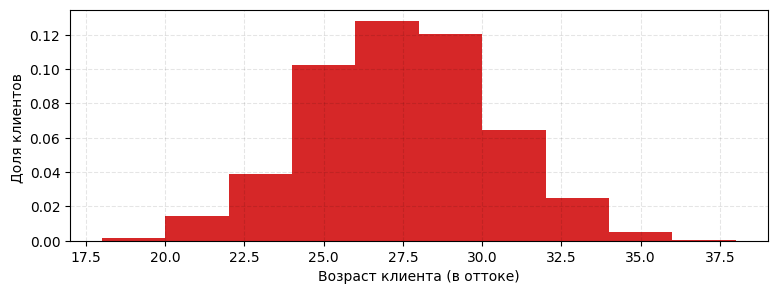

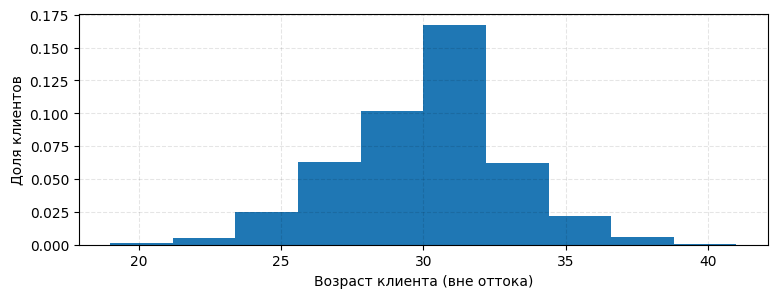

In [ ]:
data = gym_churn.query('Churn == 1')
name = 'Age'
label = 'Возраст клиента (в оттоке)'
def age1():
    plt.figure(figsize=(9,3))
    plt.hist(data[name], density=True, color='tab:red')
    plt.xlabel(label)
    plt.ylabel('Доля клиентов ')
    plt.grid(linestyle='--',alpha=0.1,color='black')
    plt.show()
age1()
#------------------------------------
data = gym_churn.query('Churn == 0')
name = 'Age'
label = 'Возраст клиента (вне оттока)'
def age0():
    plt.figure(figsize=(8.89,3))
    plt.hist(data[name], density=True, color='tab:blue')
    plt.xlabel(label)
    plt.ylabel('Доля клиентов')
    plt.grid(linestyle='--',alpha=0.1,color='black')
    plt.show()
age0()

Время с момента первого обращения

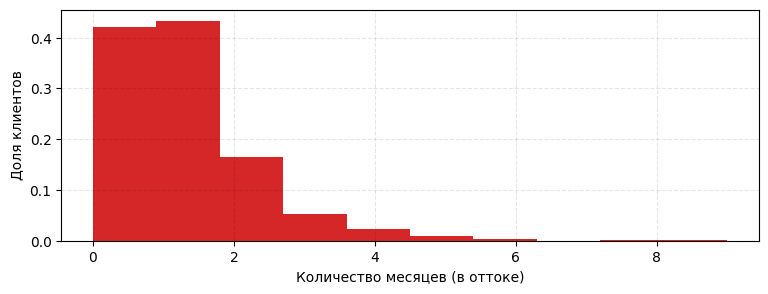

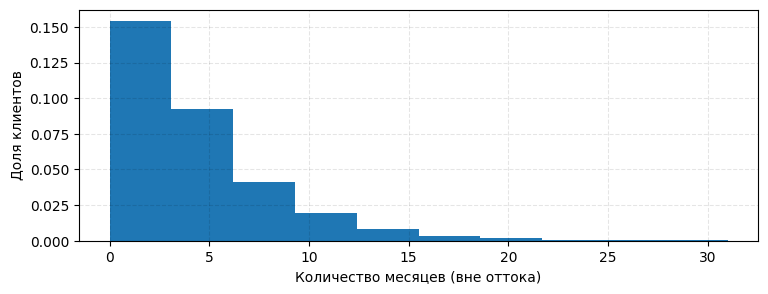

In [ ]:
data = gym_churn.query('Churn == 1')
name = 'Lifetime'
label = 'Количество месяцев (в оттоке)'
def Lifetime1():
    plt.figure(figsize=(9,3))
    plt.hist(data[name], density=True, color = 'tab:red')
    plt.xlabel(label)
    plt.ylabel('Доля клиентов')
    plt.grid(linestyle='--',alpha=0.1,color='black')
    plt.show()
Lifetime1()
#------------------------------------
data = gym_churn.query('Churn == 0')
name = 'Lifetime'
label = 'Количество месяцев (вне оттока)'
def Lifetime0():
    plt.figure(figsize=(8.77,3))
    plt.hist(data[name], density=True, color = 'tab:blue')
    plt.xlabel(label)
    plt.ylabel('Доля клиентов')
    plt.grid(linestyle='--',alpha=0.1,color='black')
    plt.show()
Lifetime0()

Средняя выручка в месяц с доп услуг

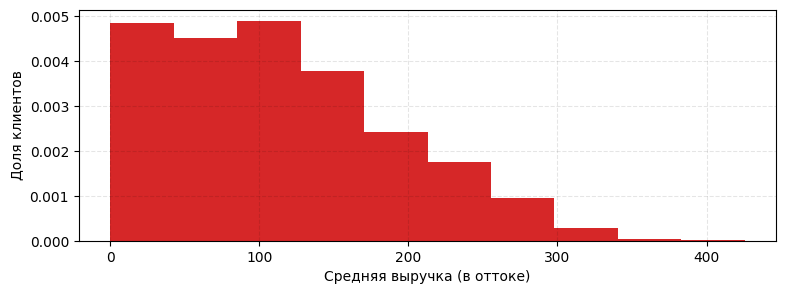

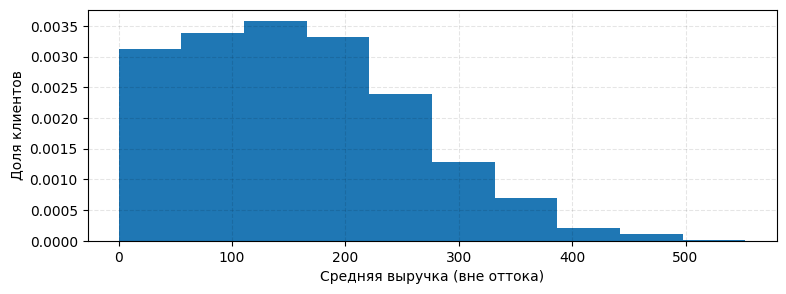

In [ ]:
data = gym_churn.query('Churn == 1')
name = 'Avg_additional_charges_total'
label = 'Средняя выручка (в оттоке)'
def Avg_additional_charges_total1():
    plt.figure(figsize=(9,3))
    plt.hist(data[name], density=True, color = 'tab:red')
    plt.xlabel(label)
    plt.ylabel('Доля клиентов')
    plt.grid(linestyle='--',alpha=0.1,color='black')
    plt.show()
Avg_additional_charges_total1()
#------------------------------------
data = gym_churn.query('Churn == 0')
name = 'Avg_additional_charges_total'
label = 'Средняя выручка (вне оттока)'
def Avg_additional_charges_total0():
    plt.figure(figsize=(8.89,3))
    plt.hist(data[name], density=True, color = 'tab:blue')
    plt.xlabel(label)
    plt.ylabel('Доля клиентов')
    plt.grid(linestyle='--',alpha=0.1,color='black')
    plt.show()
Avg_additional_charges_total0()

Средняя количесво посещений в неделю за все время

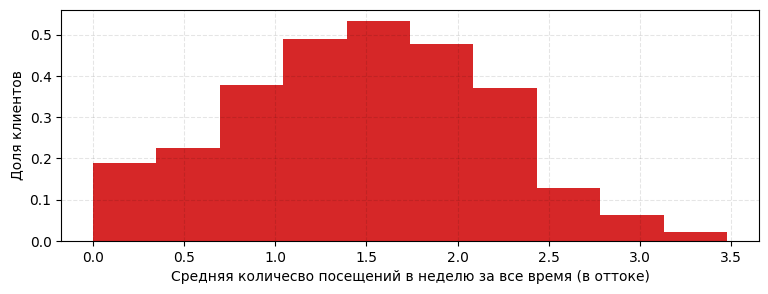

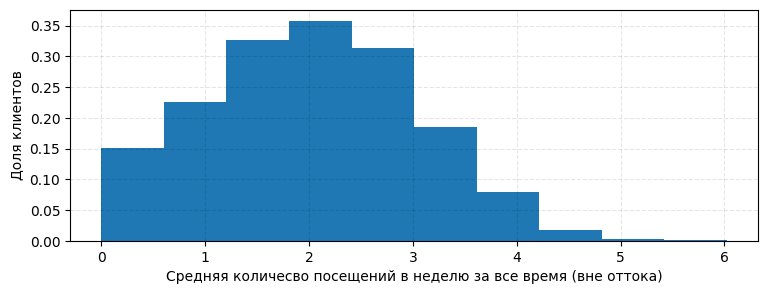

In [ ]:
data = gym_churn.query('Churn == 1')
name = 'Avg_class_frequency_total'
label = 'Средняя количесво посещений в неделю за все время (в оттоке)'
def Avg_class_frequency_total1():
    plt.figure(figsize=(9,3))
    plt.hist(data[name], density=True, color = 'tab:red')
    plt.xlabel(label)
    plt.ylabel('Доля клиентов')
    plt.grid(linestyle='--',alpha=0.1,color='black')
    plt.show()
Avg_class_frequency_total1()
#------------------------------------
data = gym_churn.query('Churn == 0')
name = 'Avg_class_frequency_total'
label = 'Средняя количесво посещений в неделю за все время (вне оттока)'
def Avg_class_frequency_total0():
    plt.figure(figsize=(8.88,3))
    plt.hist(data[name], density=True, color = 'tab:blue')
    plt.xlabel(label)
    plt.ylabel('Доля клиентов')
    plt.grid(linestyle='--',alpha=0.1,color='black')
    plt.show()
Avg_class_frequency_total0()

Среднее количесмтво посещений в неделю за последний месяц

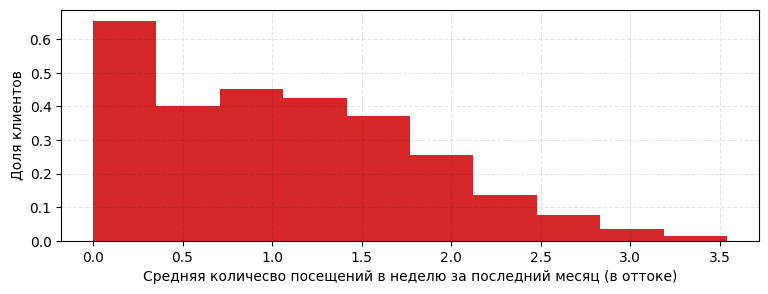

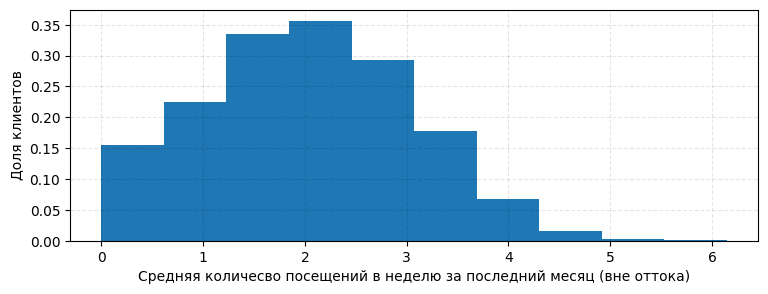

In [ ]:
data = gym_churn.query('Churn == 1')
name = 'Avg_class_frequency_current_month'
label = 'Средняя количесво посещений в неделю за последний месяц (в оттоке)'
def Avg_class_frequency_current_month1():
    plt.figure(figsize=(9,3))
    plt.hist(data[name], density=True, color = 'tab:red')
    plt.xlabel(label)
    plt.ylabel('Доля клиентов')
    plt.grid(linestyle='--',alpha=0.1,color='black')
    plt.show()
Avg_class_frequency_current_month1()
#------------------------------------
data = gym_churn.query('Churn == 0')
name = 'Avg_class_frequency_current_month'
label = 'Средняя количесво посещений в неделю за последний месяц (вне оттока)'
def Avg_class_frequency_current_month0():
    plt.figure(figsize=(8.88,3))
    plt.hist(data[name], density=True, color = 'tab:blue')
    plt.xlabel(label)
    plt.ylabel('Доля клиентов')
    plt.grid(linestyle='--',alpha=0.1,color='black')
    plt.show()
Avg_class_frequency_current_month0()

# Матрица корреляций (влияние признаков )

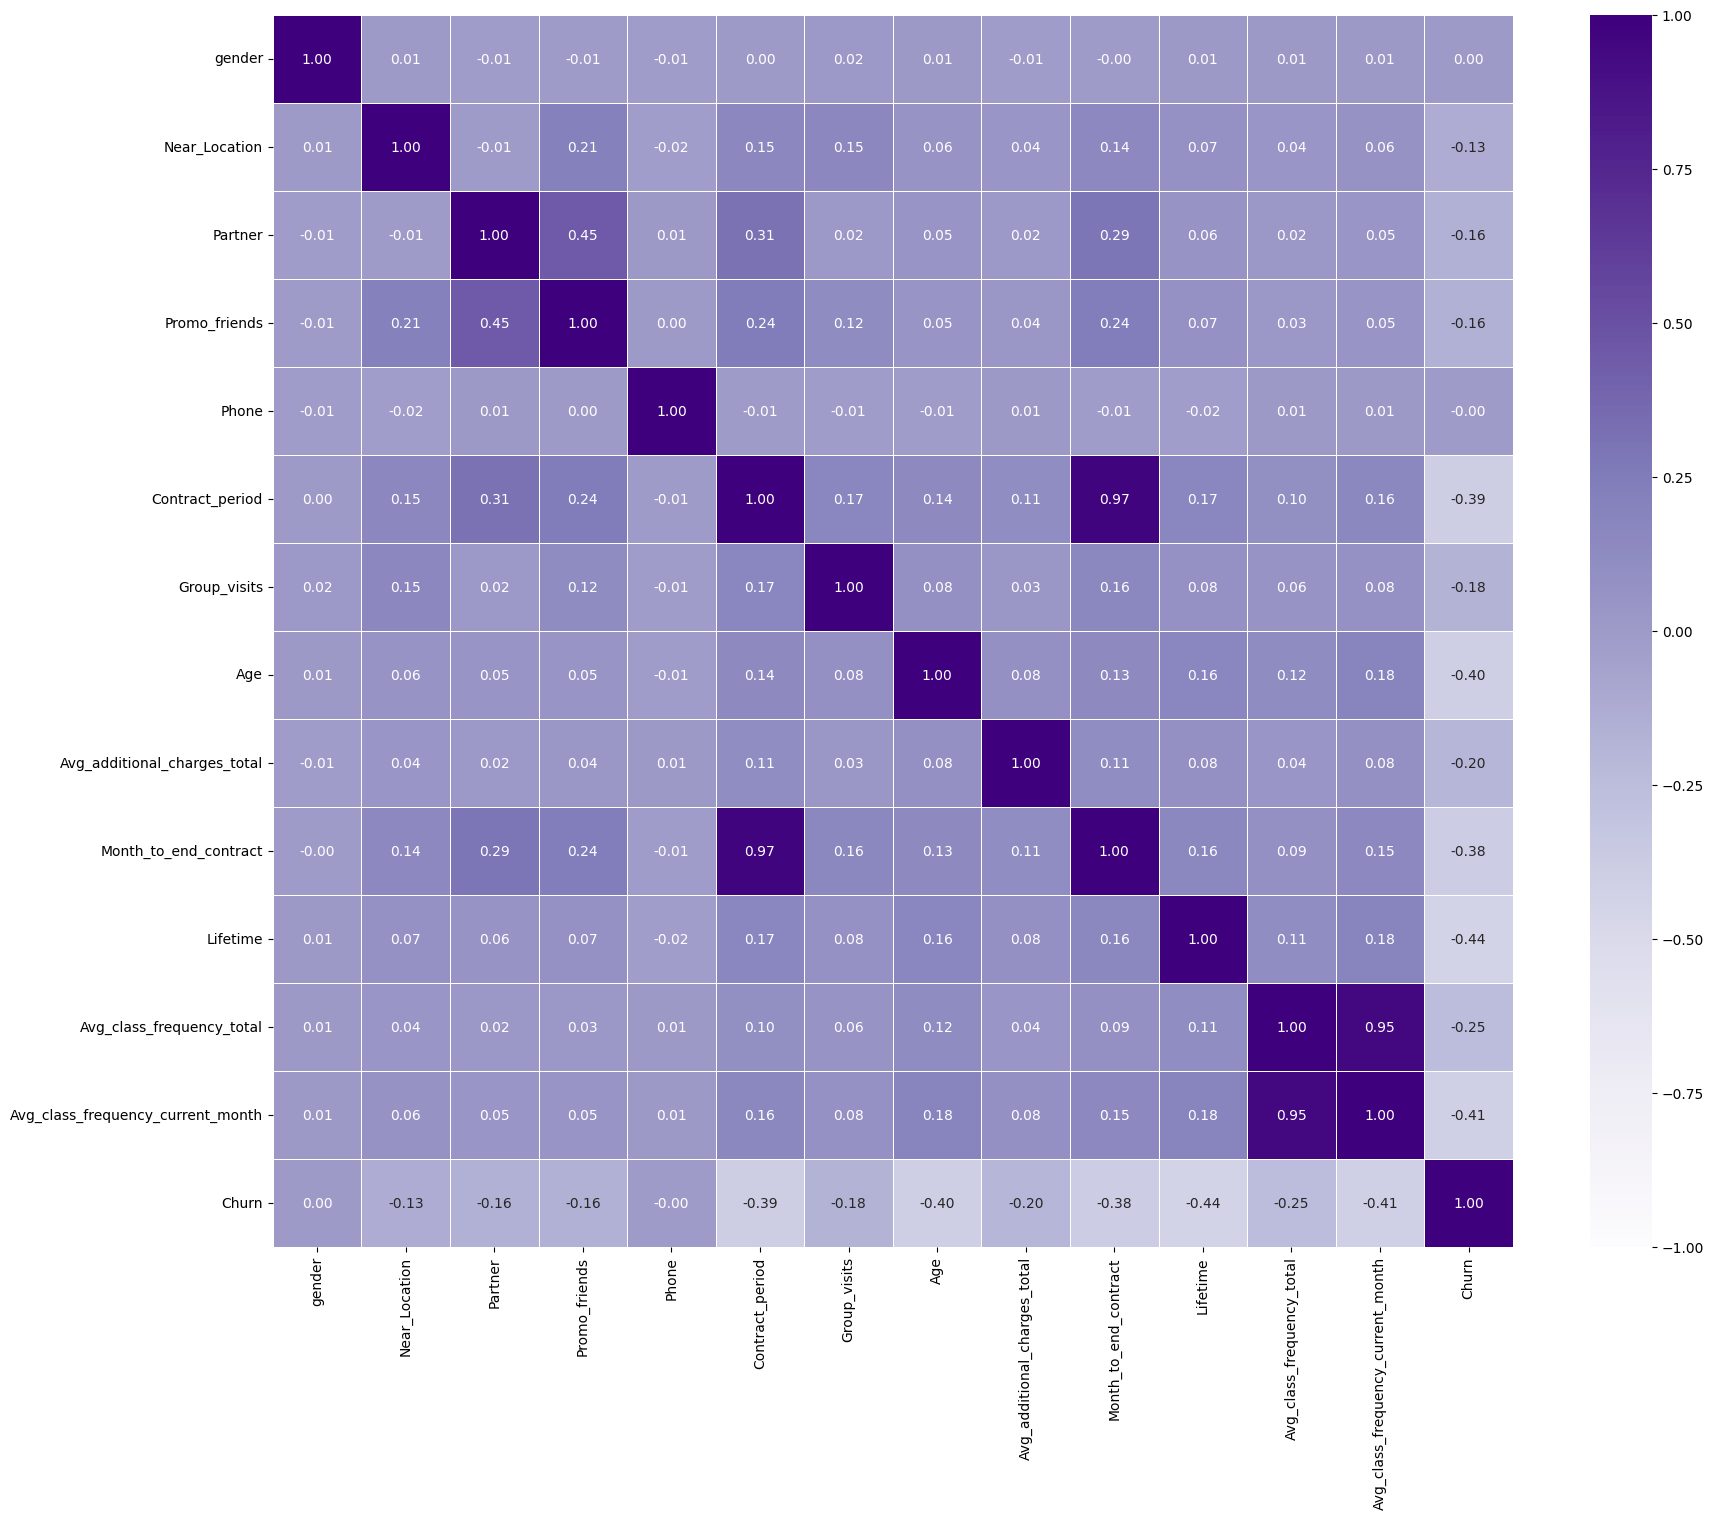

In [ ]:
plt.figure(figsize= (20,16))
sns.heatmap(gym_churn.corr(), vmin = -1, vmax = 1, annot=True, fmt='.2f', cmap='Purples', linewidths=0.5, linecolor='white')
plt.show()

# Прогноз оттока

In [ ]:
X = gym_churn.drop('Churn', axis = 1)
y = gym_churn['Churn']

In [ ]:
X_train,X_test,у_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)
у1 = у_train # переназначение переменной для корректной работы интерпретатора

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_st = scaler.transform(X_train)
X_test_st = scaler.transform(X_test)

# Логистическая регрессия

In [ ]:
model = LogisticRegression(random_state=42)
model.fit(X_train_st,у1)
lr_pred = model.predict(X_test_st)

In [ ]:
print(f'Accuracy:{accuracy_score(y_test,lr_pred)}')
print(f'Precision:{precision_score(y_test,lr_pred)}')
print(f'Recall:{recall_score(y_test,lr_pred)}')

Accuracy:0.91625
Precision:0.8729281767955801
Recall:0.7821782178217822


# Случайный лес

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,у1)
rf_pred = rf_model.predict(X_test)

In [ ]:
print(f'Accuracy:{accuracy_score(y_test,rf_pred)}')
print(f'Precision:{precision_score(y_test,rf_pred)}')
print(f'Recall:{recall_score(y_test,rf_pred)}')

Accuracy:0.91
Precision:0.8494623655913979
Recall:0.7821782178217822


На основании метрик модель лоистичекой регрессии показала себя немного лучше в показателе 'Accuracy', по остальным 2-м показателям, модели рассчитали одинаковый результат.

# Кластеризация

In [ ]:
sc = StandardScaler()
X_st = sc.fit_transform(X)

Матрица расстояний

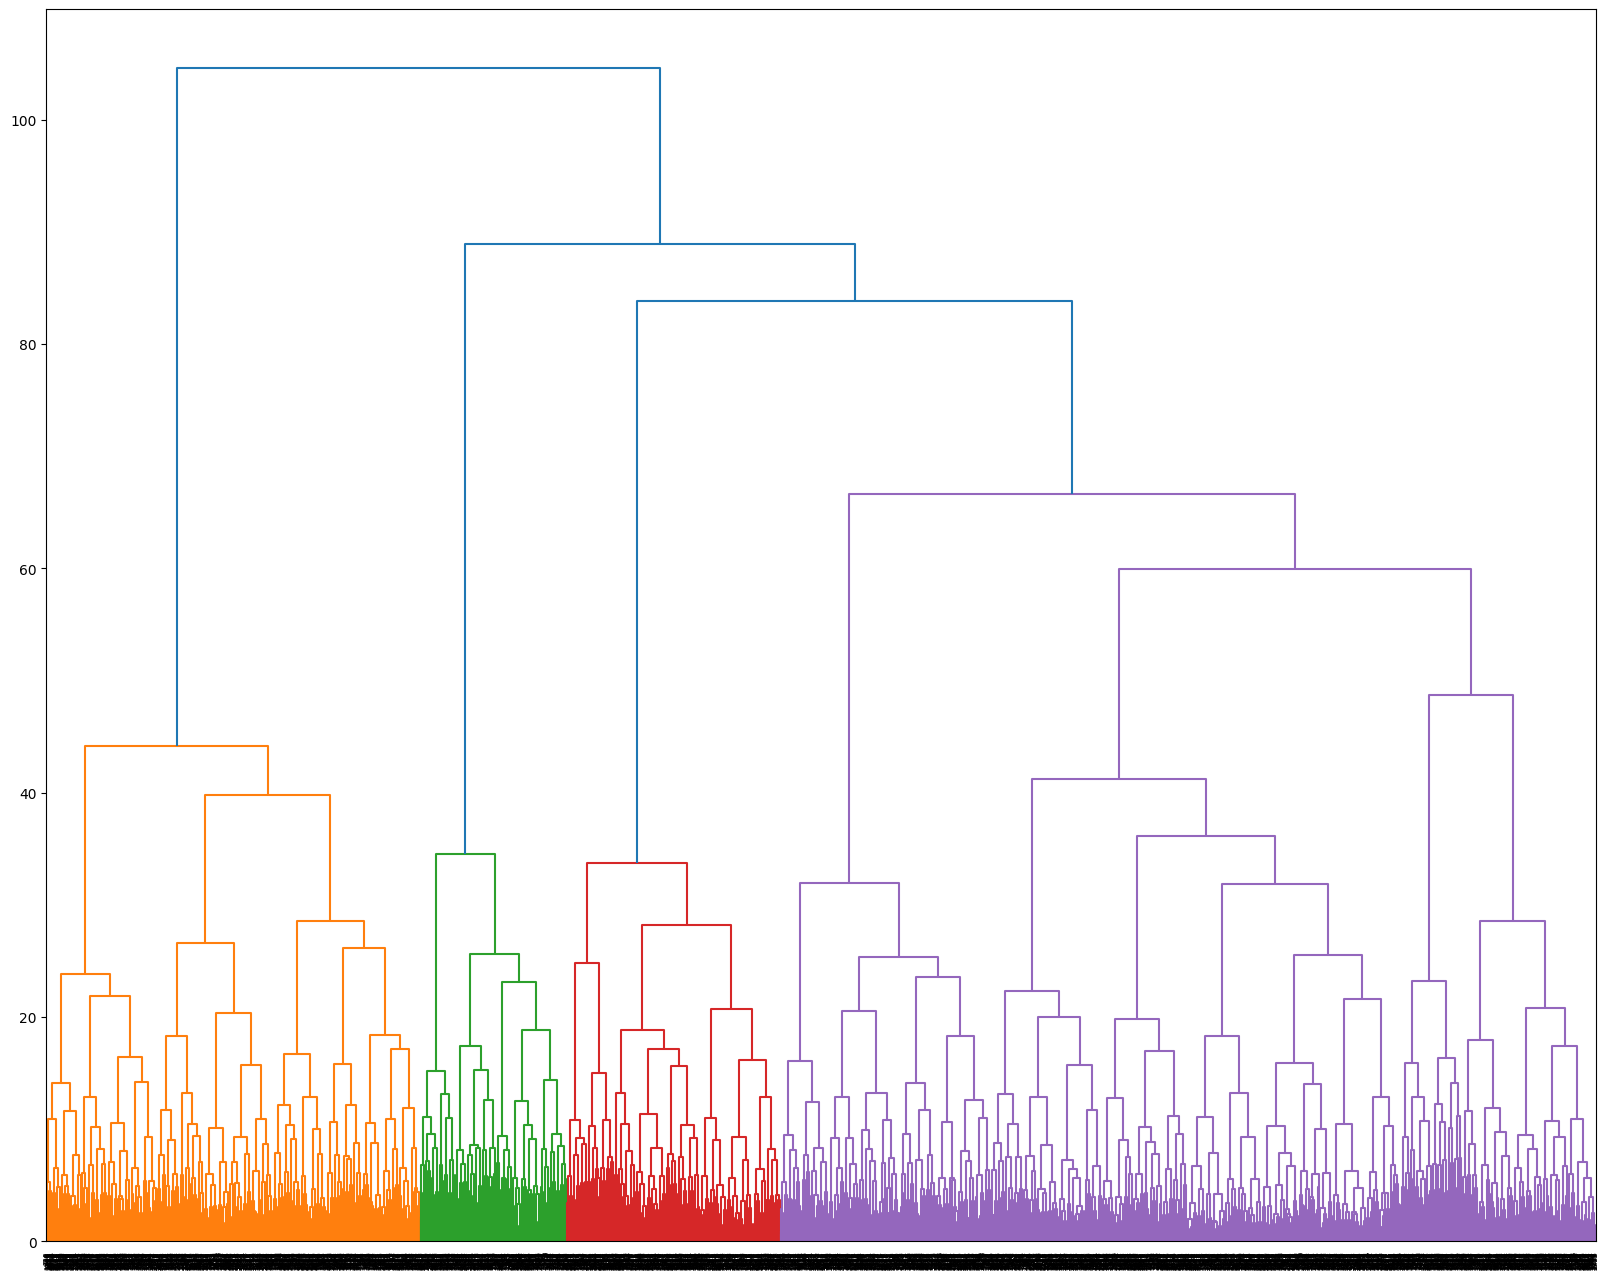

In [ ]:
linked = linkage(X_st,method='ward')
plt.figure(figsize = (20,16))
dendrogram(linked,orientation = 'top')
plt.show()

# Кластеризация

In [ ]:
km = KMeans(n_clusters=4)
labels =  km.fit_predict(X_st)
gym_churn['cluster'] = labels

Отобразим средние признаки кластеров

In [ ]:
c = gym_churn.groupby('cluster').agg('mean')
print(c.T)

cluster                                     0           1           2  \
gender                               0.503119    0.484588    0.568421   
Near_Location                        0.935551    0.723297    0.855789   
Partner                              0.737006    0.298925    0.269474   
Promo_friends                        0.474012    0.012186    0.072632   
Phone                                0.899168    0.901792    0.911579   
Contract_period                     11.819127    1.886022    2.712632   
Group_visits                         0.549896    0.274552    0.449474   
Age                                 29.873181   28.130466   30.026316   
Avg_additional_charges_total       164.766490  128.759875  158.820795   
Month_to_end_contract               10.816008    1.799283    2.512632   
Lifetime                             4.701663    2.221505    4.981053   
Avg_class_frequency_total            1.980820    1.262862    2.790414   
Avg_class_frequency_current_month    1.972726    1.

Проведем визуализацию кластеризации

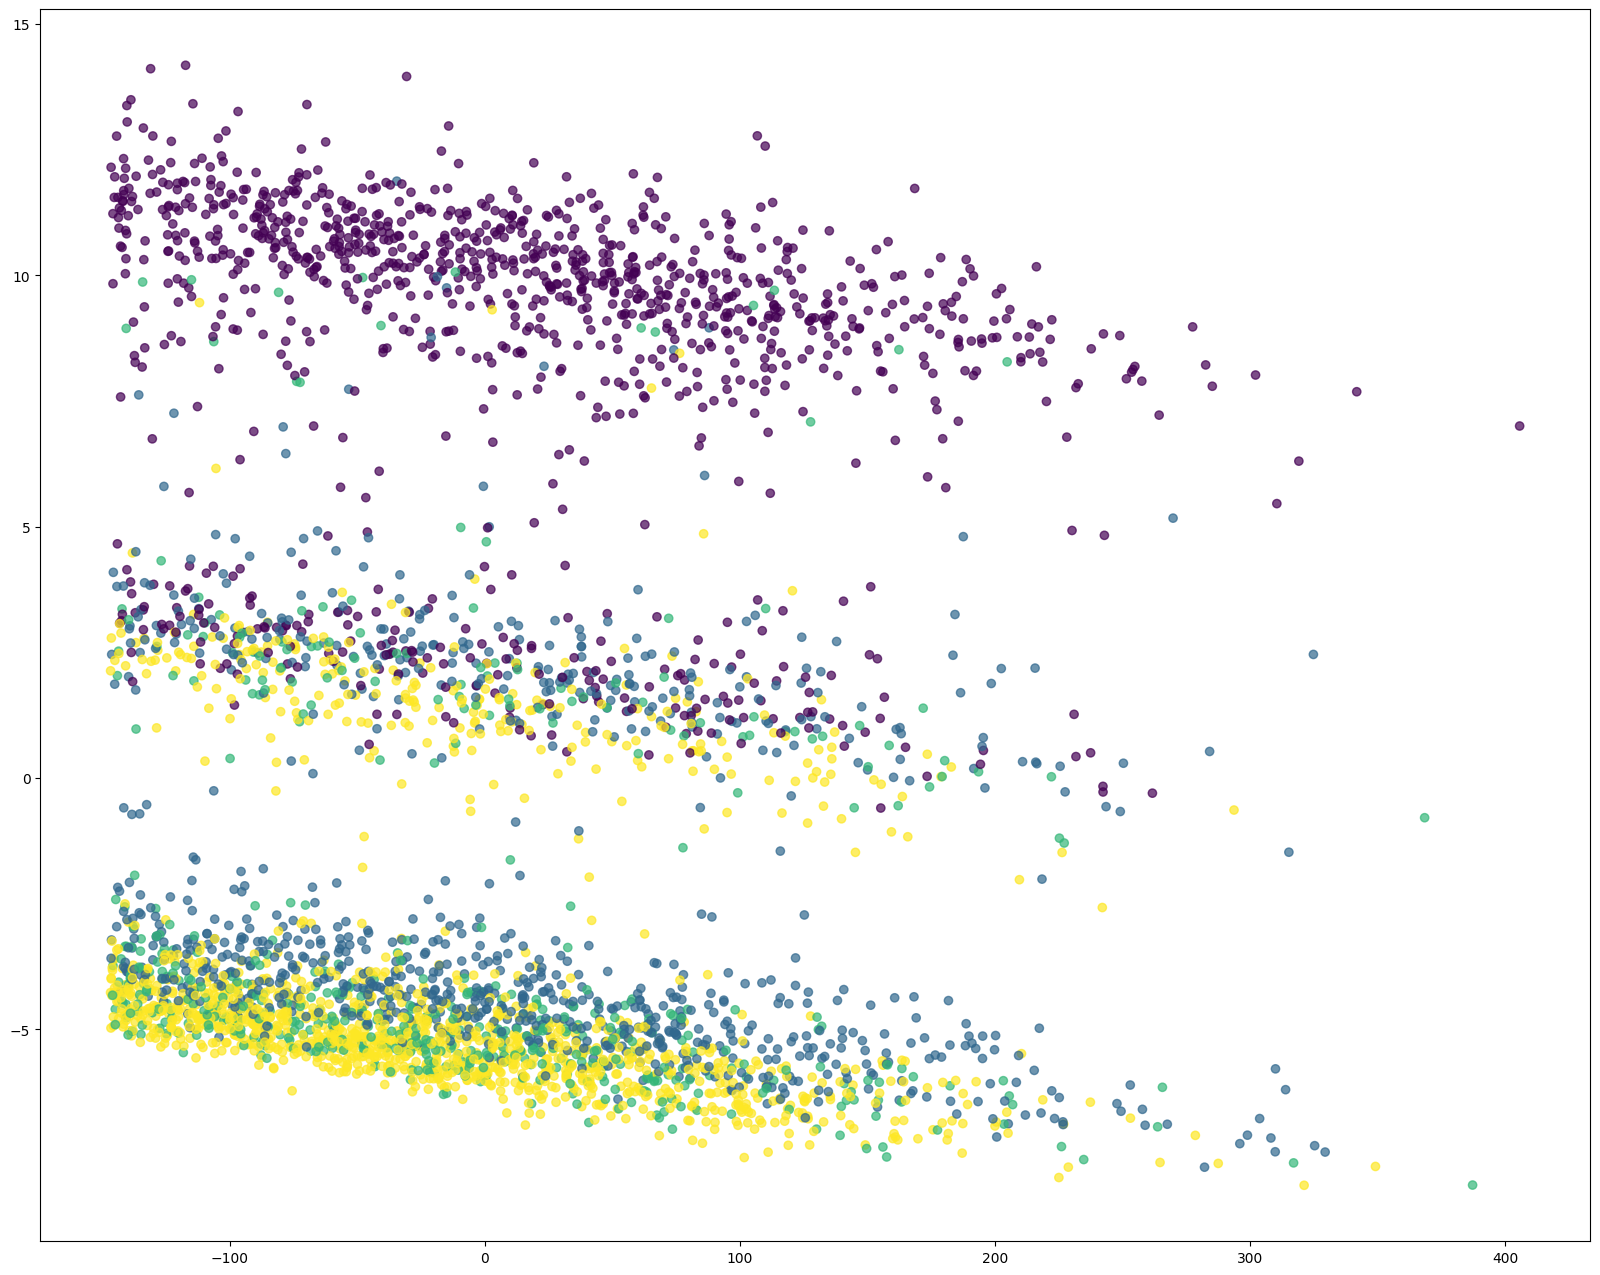

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(gym_churn)
plt.figure(figsize=(20, 16))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='viridis', alpha=0.7)

Представим доли оттоков клинтов по кластерам

In [ ]:
print (c1 := round(c['Churn'],3))

cluster
0    0.028
1    0.073
2    0.443
3    0.525
Name: Churn, dtype: float64


# Выводы и Рекомендации

Выводы:

1. Исходя из представленной статистики  кластеров, можно заметить разное распределение оттока клинтов по кластерам.

Кластер 0: Низкий отток (2.8%)

Кластер 1: Умеренный отток (7.3%)

Кластер 2: Высокий отток (44.3%)

Кластер 3: Самый высокий отток (52.5%)

2.  Contract_period и Month_to_end_contract сильно различаются.

Кластер 0: долгий контракт (~10,9 мес)

Кластеры 1–3: короткие контракты (1.9–2.6 мес).

Можно сказать что клиенты с короткими контрактами склонны уходить чаще.

3. При рассмотрении показателей
Avg_class_frequency_total и Avg_class_frequency_current_month

наблюдаеться, что у кластера 1 частота посещения высокая, равна 2.8, а у кластера 2–3 низкая частота ~1.2 - 1.7, особенно в текущем месяце 0.99 - 1.49.
В данном наблюдении, снижение частоты посещений - явный индикатор риска оттока клиентов.

Рекомендовать можно следующее:

1. Сфокусироваться на кластерах 2 и 3 - предложить персональные акции, напоминания, мотивационные программы для увеличения посещения тренировок.

2. Стимулировать продление контрактов

3. Увеличить вовлечённость через групповые занятия, программы с друзьями, партнёрские акции.